In [ ]:
## Грибушенков Михаил, РФЗ-2, Л/Р №9. Обучение с подкреплением - дописывание кода примера. Оригинальные комментарии вырезаны.



#**И будь трижды неладен JAХ, несовместимый с выражениями if, else, and, or .**


### Настраиваем среду

In [77]:
# @title Установка необходимых пакетов (надо просто запустить!) { display-mode: "form" }
# @markdown Может занять несколько минут
%%capture
!pip install jaxlib
!pip install jax
!pip install git+https://github.com/deepmind/dm-haiku
!pip install gym==0.25
!pip install gym[box2d]
!pip install optax
!pip install matplotlib
!pip install chex
!pip install gym[classic_control]

In [78]:
# @title Импорт необходимых пакетов (просто запустите ячейку) { display-mode: "form" }
%%capture
import copy
from shutil import rmtree # deleting directories
import random
import collections # useful data structures
import numpy as np
import gym # reinforcement learning environments
from gym.wrappers import RecordVideo
import jax
import jax.numpy as jnp # jax numpy
import haiku as hk # jax neural network library
import optax # jax optimizer library
import matplotlib.pyplot as plt # graph plotting library
from IPython.display import HTML
from base64 import b64encode
import chex

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

In [79]:
# Создание среды для обучения
env_name = "CartPole-v0"
env = gym.make(env_name)

In [80]:
# Сброс среды
s_0 = env.reset()
print("Initial State::", s_0)

# Получение формы пространства параметров среды
obs_shape = env.observation_space.shape
print("Environment Obs Space Shape:", obs_shape)

Initial State:: [-0.00030205  0.03918411 -0.00978906  0.04011435]
Environment Obs Space Shape: (4,)


В CartPole состояние окружающей среды представлено четырьмя числами: *угловое положение **полюса** (не полюса (pole), а шеста (pole) - корявый машинный перевод - прим. меня), угловая скорость полюса, положение тележки, скорость тележки*.

In [81]:
# Get action space - e.g. discrete or continuous
print(f"Environment action space: {env.action_space}")

# Get num actions
num_actions = env.action_space.n
print(f"Number of actions: {num_actions}")

Environment action space: Discrete(2)
Number of actions: 2


In [98]:
linear_policy = lambda params, obs: jax.lax.select(jax.numpy.dot (params, obs)>0, 1, 0 )
# : )



In [84]:
# @title Проверка упр 1  { display-mode: "form" }

def check_linear_policy(linear_policy):
  fixed_obs = jnp.array([1,1,2,4])

  # check case1 - negative dot product.
  # weights
  params1 = jnp.array([1,1,1,1])
  params2 = jnp.array([-1,-1,-1,-1])

  hint1 = f"Неправильный ответ, ваша линейная политика неверна. Действие при \
obs={fixed_obs} и params={params1} должно быть 1"

  hint2 = f"Неправильный ответ, ваша линейная политика неверна. Действие при \
obs={fixed_obs} и params={params2} должно быть 0"

  hint = None
  if linear_policy(params1, fixed_obs) != 1:
    hint = hint1
  elif linear_policy(params2, fixed_obs) != 0:
    hint = hint2

  if hint is not None:
    print(hint)
  else:
    print("Your function is correct!")

try:
  check_linear_policy(linear_policy)
except Exception as e:
    print("An Error Occured: {}".format(e))

Your function is correct!


In [99]:
# А без этого ничего не работает, есть такая зависимость у нумпу.

!pip install git+https://github.com/CadQuery/cadquery.git

  Cloning https://github.com/CadQuery/cadquery.git to /tmp/pip-req-build-jqbbkwc7
  Running command git clone --filter=blob:none --quiet https://github.com/CadQuery/cadquery.git /tmp/pip-req-build-jqbbkwc7
  Resolved https://github.com/CadQuery/cadquery.git to commit f86ff79fb1c6fff8b7751c204bfeab5c3fc6a096
  Preparing metadata (setup.py) ... done


In [100]:
# Get the initial obs by resetting the env
initial_obs = env.reset()

# Randomly sample actions from env
action = env.action_space.sample()

# Step the environment
next_obs, reward, done, info = env.step(action)

print("Observation:", initial_obs)
print("Action:", action)
print("Next observation:", next_obs)
print("Reward:", reward)
print("Game is done:", done)

Observation: [ 0.00043197  0.03975723 -0.03925446  0.02492765]
Action: 0
Next observation: [ 0.00122712 -0.15478045 -0.03875591  0.30497152]
Reward: 1.0
Game is done: False


In [101]:
def run_episode(env):
    episode_return = 0 # counter to keep track of rewards
    done = False # initially set to False
    params = jnp.array([1,-2,2,-1]) # fixed policy parameters

    ## YOUR CODE

    obs = env.reset()

    while not done: # loop until episode is done
        action = np.array(linear_policy(params, obs))
        obs, reward, done, info = env.step(action)
        episode_return += reward

    return episode_return

In [102]:
# @title Проверка упр 2 (run me) { display-mode: "form" }

try:
  env.seed(42)
  if run_episode(env) == 31:
    print("Looks correct!")
  else:
    print("Looks like your implementation might be wrong.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Looks correct!


In [103]:
#@title Training loop (run me) { display-mode: "form" }

# NamedTuple to store transitions
Transition = collections.namedtuple("Transition", ["obs", "action", "reward", "next_obs", "done"])

# Training Loop
def run_training_loop(env_name, agent_params, agent_select_action_func,
    agent_actor_state=None, agent_learn_func=None, agent_learner_state=None,
    agent_memory=None, num_episodes=1000, evaluator_period=100,
    evaluation_episodes=8, learn_steps_per_episode=1,
    train_every_timestep=False, video_subdir="",):
    """
    This function runs several episodes in an environment and periodically does
    some agent learning and evaluation.

    Args:
        env: a gym environment.
        agent_params: an object to store parameters that the agent uses.
        agent_select_func: a function that does action selection for the agent.
        agent_actor_state (optional): an object that stores the internal state
            of the agents action selection function.
        agent_learn_func (optional): a function that does some learning for the
            agent by updating the agent parameters.
        agent_learn_state (optional): an object that stores the internal state
            of the agent learn function.
        agent_memory (optional): an object for storing an retrieving historical
            experience.
        num_episodes: how many episodes to run.
        evaluator_period: how often to run evaluation.
        evaluation_episodes: how many evaluation episodes to run.
        train_every_timestep: whether to train every timestep rather than at the end
            of the episode.
        video_subdir: subdirectory to store epsiode recordings.

    Returns:
        episode_returns: list of all the episode returns.
        evaluator_episode_returns: list of all the evaluator episode returns.
    """

    # Setup Cartpole environment and recorder
    env = gym.make(env_name, render_mode="rgb_array") # training environment
    eval_env = gym.make(env_name, render_mode="rgb_array") # evaluation environment

    # Video dir
    video_dir = "./video"+"/"+video_subdir

    # Clear video dir
    try:
      rmtree(video_dir)
    except:
      pass

    # Wrap in recorder
    env = RecordVideo(env, video_dir+"/train", episode_trigger=lambda x: (x % evaluator_period) == 0)
    eval_env = RecordVideo(eval_env, video_dir+"/eval", episode_trigger=lambda x: (x % evaluation_episodes) == 0)

    # JAX random number generator
    rng = hk.PRNGSequence(jax.random.PRNGKey(0))
    env.seed(0) # seed environment for reproducability
    random.seed(0)

    episode_returns = [] # List to store history of episode returns.
    evaluator_episode_returns = [] # List to store history of evaluator returns.
    timesteps = 0
    for episode in range(num_episodes):

        # Reset environment.
        obs = env.reset()
        episode_return = 0
        done = False

        while not done:

            # Agent select action.
            action, agent_actor_state = agent_select_action_func(
                                            next(rng),
                                            agent_params,
                                            agent_actor_state,
                                            np.array(obs)
                                        )

            # Step environment.
            next_obs, reward, done, _ = env.step(int(action))

            # Pack into transition.
            transition = Transition(obs, action, reward, next_obs, done)

            # Add transition to memory.
            if agent_memory: # check if agent has memory
              agent_memory.push(transition)

            # Add reward to episode return.
            episode_return += reward

            # Set obs to next obs before next environment step. CRITICAL!!!
            obs = next_obs

            # Increment timestep counter
            timesteps += 1

            # Maybe learn every timestep
            if train_every_timestep and (timesteps % 4 == 0) and agent_memory and agent_memory.is_ready(): # Make sure memory is ready
                # First sample memory and then pass the result to the learn function
                memory = agent_memory.sample()
                agent_params, agent_learner_state = agent_learn_func(
                                                        next(rng),
                                                        agent_params,
                                                        agent_learner_state,
                                                        memory
                                                    )

        episode_returns.append(episode_return)

        # At the end of every episode we do a learn step.
        if agent_memory and agent_memory.is_ready(): # Make sure memory is ready

            for _ in range(learn_steps_per_episode):
                # First sample memory and then pass the result to the learn function
                memory = agent_memory.sample()
                agent_params, agent_learner_state = agent_learn_func(
                                                        next(rng),
                                                        agent_params,
                                                        agent_learner_state,
                                                        memory
                                                    )

        if (episode % evaluator_period) == 0: # Do evaluation

            evaluator_episode_return = 0
            for eval_episode in range(evaluation_episodes):
                obs = eval_env.reset()
                done = False
                while not done:
                    action, _ = agent_select_action_func(
                                    next(rng),
                                    agent_params,
                                    agent_actor_state,
                                    np.array(obs),
                                    evaluation=True
                                )

                    obs, reward, done, _ = eval_env.step(int(action))

                    evaluator_episode_return += reward

            evaluator_episode_return /= evaluation_episodes

            evaluator_episode_returns.append(evaluator_episode_return)

            logs = [
                    f"Episode: {episode}",
                    f"Episode Return: {episode_return}",
                    f"Average Episode Return: {np.mean(episode_returns[-20:])}",
                    f"Evaluator Episode Return: {evaluator_episode_return}"
            ]

            print(*logs, sep="\t") # Print the logs

    env.close()
    eval_env.close()

    return episode_returns, evaluator_episode_returns

In [104]:
# Parameter container for Random Policy Search
RandomPolicySearchParams = collections.namedtuple("RandomPolicySearchParams", ["current", "best"])

# TEST: store two different sets of parameters
current_params = np.ones(obs_shape) * -1
best_params = np.zeros(obs_shape)
rps_params = RandomPolicySearchParams(current_params, best_params)

# How to access the best or current params.
print(f"Best params: {rps_params.best}")
print(f"Current params: {rps_params.current}")

Best params: [0. 0. 0. 0.]
Current params: [-1. -1. -1. -1.]


In [131]:
def random_policy_search_choose_action(
    key,
    params,
    actor_state,
    obs,
    evaluation=False
):
    """Random policy search select action method.

    Args:
        key: a random number (seed). Not used in this function.
        params: the agent's parameters. In this case an instance of `RandomPolicySearchParams`
        actor_state: some extra information about the actor. Not used in this function.
        obs: the latest observation.
        evaluation: a boolean indicating whether to use the best "parameters" or the "current" ones.

    Returns:
        The chosen action and the updated actor_state. In this function the actor_state is not updated.
    """
    return jax.lax.select (evaluation, linear_policy(params.best, obs), linear_policy(params.current, obs)), actor_state

In [132]:
# @title Проверка упр 3 (run me) {display-mode: "form"}

def check_random_policy_search_choose_action(choose_action):
  key = None # not used
  actor_state = None # not used

  # obs
  obs = np.ones(obs_shape)

  evaluation=False
  current_params = np.ones(obs_shape) * -1
  best_params = np.ones(obs_shape)
  rps_params = RandomPolicySearchParams(current_params, best_params)
  action, actor_state = choose_action(key,rps_params,actor_state,obs,evaluation)
  if action != 0:
    return False

  evaluation=True
  current_params = np.ones(obs_shape) * -1
  best_params = np.ones(obs_shape)
  rps_params = RandomPolicySearchParams(current_params, best_params)
  action, actor_state = choose_action(key,rps_params,actor_state,obs,evaluation)
  if action != 1:
    return False

  return True

try:
  if check_random_policy_search_choose_action(random_policy_search_choose_action):
    print("Your function looks correct.")
  else:
    print("Your function looks incorrect.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Your function looks correct.


In [133]:
class AverageEpisodeReturnBuffer:

    def __init__(self, num_episodes_to_store=50):
        """
        This class implements an agent memory that stores the average episode
        return over the last 50 episodes.
        """
        self.num_episodes_to_store = num_episodes_to_store
        self.episode_return_buffer = []
        self.current_episode_return = 0

    def push(self, transition):
        self.current_episode_return += transition.reward

        if transition.done: # If the episode is done
            # Add episode return to buffer
            self.episode_return_buffer.append(self.current_episode_return)

            # Reset episode return
            self.current_episode_return = 0


    def is_ready(self):
        return len(self.episode_return_buffer) == self.num_episodes_to_store

    def sample(self):
        average_episode_return = np.mean(self.episode_return_buffer)

        # Clear episode return buffer
        self.episode_return_buffer = []

        return average_episode_return

In [130]:
def get_new_random_weights(random_key, old_weights, minval=-2.0, maxval=2.0):
    new_weights_shape = old_weights.shape # you will need to use these values

    new_params = jax.random.uniform(random_key, [4], minval=minval, maxval=maxval).astype("float32")

    return new_params

In [121]:
# @title Проверка упр 4 (run me) {display-mode: "form"}

def check_get_new_random_weights(get_new_random_weights):
  old_weights = np.ones(obs_shape, "float32")
  random_key = jax.random.PRNGKey(42)

  # Case 1
  new_weights = get_new_random_weights(random_key, old_weights, minval=-2.0, maxval=2.0)

  if jnp.array_equal(new_weights, jnp.array([ 0.29657745,1.4265499, -1.7621555, -1.7505779 ])):
    print("Function is correct!")
  else:
    print("Something is wrong.")
    print (new_weights)

try:
  check_get_new_random_weights(get_new_random_weights)
except Exception as e:
    print("An Error Occured: {}".format(e))

Something is wrong.
[-0.04516172  0.7191887   0.46508598  0.24406433]


(Все нормально, ничего не вронг. Вероятно, сменилась реализация генератора случайных чисел.)

In [114]:
# A NamedTuple to store the best average episode return so far
RandomPolicyLearnState = collections.namedtuple(
  "RandomPolicyLearnState",
  ["best_average_episode_return"]
)

# Test
initial_learn_state = RandomPolicyLearnState(best_average_episode_return=-float("inf"))
print("Initial best average episode return:", initial_learn_state.best_average_episode_return)

Initial best average episode return: -inf


In [115]:
def random_policy_search_learn(key, params, learn_state, memory):
    best_params = params.best
    current_params = params.current

    current_average_episode_return = memory # the memory contains the average episode return
    best_average_episode_return = learn_state.best_average_episode_return


    best_params = jax.lax.select(current_average_episode_return > best_average_episode_return, current_params, best_params)
    best_average_episode_return = jax.lax.select(current_average_episode_return > best_average_episode_return,
                                                 current_average_episode_return,
                                                 best_average_episode_return)

    # Generate new random parameters
    new_params = get_new_random_weights(key, current_params)

    # Bundle weights in RandomPolicySearchParams NamedTuple
    params = RandomPolicySearchParams(current=new_params, best=best_params)

    return params, RandomPolicyLearnState(best_average_episode_return)

In [116]:
#@title Проверка упр 5 {display-mode: "form"}

params = RandomPolicySearchParams(np.ones(obs_shape, "float32"), np.ones(obs_shape, "float32") * -1)
learn_state = RandomPolicyLearnState(10)
memory = 11
key = jax.random.PRNGKey(42)

try:
  new_params, new_learn_state = random_policy_search_learn(key, params, learn_state, memory)

  if not jnp.array_equal(new_params.current, jnp.array([ 0.29657745,  1.4265499 , -1.7621555 , -1.7505779 ])):
    print("Your function is incorrect.")

  elif not jnp.array_equal(new_params.best, jnp.array([1., 1., 1., 1.])):
    print("Your function is incorrect.")

  elif new_learn_state.best_average_episode_return != 11:
    print("Your function is incorrect.")

  else:
    print("Your function looks correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Your function is incorrect.


(врет он все, ничего не инкоррект.)

In [137]:
# JIT the learn and choose action functions
random_policy_search_learn_jit = jax.jit(random_policy_search_learn)
random_policy_search_choose_action_jit = jax.jit(random_policy_search_choose_action)

# Initialise the parameters
initial_weights = np.ones(obs_shape, "float32")
initial_params = RandomPolicySearchParams(initial_weights, initial_weights)

# Initialise the learn state
initial_learn_state = RandomPolicyLearnState(best_average_episode_return=-float("inf"))

# Initialise memory
memory = AverageEpisodeReturnBuffer(num_episodes_to_store=50)

np.bool8 = np.bool_
# Run the training loop
print("Starting training. This may take up to 5 minutes to complete.")
chex.clear_trace_counter()
episode_return, evaluator_episode_returns = run_training_loop(
                                        env_name,
                                        initial_params,
                                        random_policy_search_choose_action_jit,
                                        None, # no actor state
                                        random_policy_search_learn_jit,
                                        initial_learn_state,
                                        memory,
                                        num_episodes=1201,
                                        video_subdir="rps"
                                    )

Starting training. This may take up to 5 minutes to complete.
Episode: 0	Episode Return: 80.0	Average Episode Return: 80.0	Evaluator Episode Return: 144.0
Episode: 100	Episode Return: 200.0	Average Episode Return: 108.95	Evaluator Episode Return: 115.125
Episode: 200	Episode Return: 10.0	Average Episode Return: 9.9	Evaluator Episode Return: 200.0
Episode: 300	Episode Return: 10.0	Average Episode Return: 182.4	Evaluator Episode Return: 200.0
Episode: 400	Episode Return: 28.0	Average Episode Return: 70.95	Evaluator Episode Return: 200.0
Episode: 500	Episode Return: 19.0	Average Episode Return: 188.3	Evaluator Episode Return: 200.0
Episode: 600	Episode Return: 108.0	Average Episode Return: 14.1	Evaluator Episode Return: 200.0
Episode: 700	Episode Return: 9.0	Average Episode Return: 9.2	Evaluator Episode Return: 200.0
Episode: 800	Episode Return: 9.0	Average Episode Return: 9.3	Evaluator Episode Return: 200.0
Episode: 900	Episode Return: 134.0	Average Episode Return: 15.6	Evaluator Episode

1200 эпизодов оказалось достаточно.

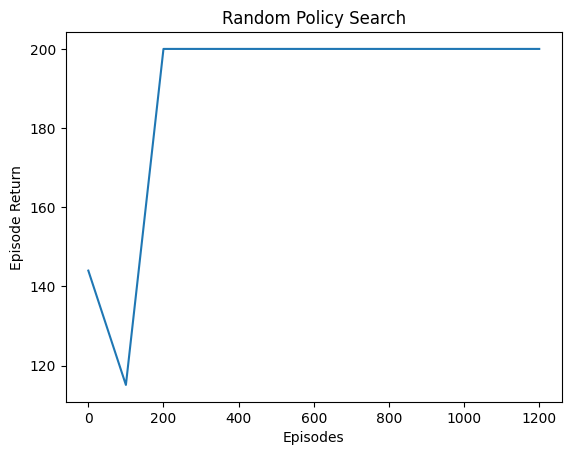

In [139]:

# Plot graph of evaluator episode returns
plt.plot(np.linspace(0, 1200, len(evaluator_episode_returns)), evaluator_episode_returns)
plt.title("Random Policy Search")
plt.xlabel("Episodes")
plt.ylabel("Episode Return")
plt.show()

Получился прекрасный квадратный корень, а подходящие параметры обнаружились уже на второй сотне эпизодов.

In [141]:
#@title Visualise Policy {display-mode: "form"}
#@markdown Choose an episode number that is a multiple of 100 and less than or equal to 1200, and **run** this cell.
episode_number = 200 #@param {type:"number"}

assert (episode_number % 100) == 0, "Episode number must be a multiple of 100 since we only record every 100th episode."
assert episode_number < 1001, "Episode number must be less than or equal to 2000"

eval_episode_number = int(episode_number / 100 * 8)
video_path = f"./video/rps/eval/rl-video-episode-{eval_episode_number}.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [142]:
compute_weighted_log_prob = lambda action_prob, episode_return: jax.numpy.log (action_prob) * episode_return

In [143]:
#@title Проверка упр 6 {display-mode: "form"}

try:
  action_prob = 0.8
  episode_return = 100
  result = compute_weighted_log_prob(action_prob, episode_return)
  if result != -22.314354:
    print("Your implementation looks incorrect.")
  else:
    print("Looks correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Looks correct.


In [148]:
def compute_rewards_to_go(rewards):
    """
    This function should take a list of rewards as input and
    compute the rewards-to-go for each timestep.

    EXAMPLE: compute_rewards_to_go([1,2,3,4]) = [10, 9, 7, 4]

    Arguments:
        rewards[t] is the reward at time step t.

    Returns:
        rewards_to_go[t] should be the reward-to-go at timestep t.
    """
    rewards_flipped = rewards[::-1]
    rewards_to_go = [sum(rewards_flipped[0:i+1]) for i in range(len(rewards_flipped)) ] [::-1]

    return rewards_to_go

In [150]:
#@title Проверка упр 7 {display-mode: "form"}

try:
  result = compute_rewards_to_go([1,2,3,4])

  if result != [10, 9, 7, 4]:
    print("There is a problem with your implementation.")
  else:
    print("Looks correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))


Looks correct.


In [151]:
# @title Реализация памяти (run me) {display-mode: "form"}

# NamedTuple to store memory
EpisodeRewardsToGoMemory = collections.namedtuple("EpisodeRewardsToGoMemory", ["obs", "action", "reward_to_go"])

class EpisodeRewardsToGoBuffer:

    def __init__(self, num_transitions_to_store=512, batch_size=256):
        self.batch_size = batch_size
        self.memory_buffer = collections.deque(maxlen=num_transitions_to_store)
        self.current_episode_transition_buffer = []

    def push(self, transition):
        self.current_episode_transition_buffer.append(transition)

        if transition.done:

            episode_rewards = []
            for t in self.current_episode_transition_buffer:
                episode_rewards.append(t.reward)

            r2g = compute_rewards_to_go(episode_rewards)

            for i, t in enumerate(self.current_episode_transition_buffer):
                memory = EpisodeRewardsToGoMemory(t.obs, t.action, r2g[i])
                self.memory_buffer.append(memory)

            # Reset episode buffer
            self.current_episode_transition_buffer = []


    def is_ready(self):
        return len(self.memory_buffer) >= self.batch_size

    def sample(self):
        random_memory_sample = random.sample(self.memory_buffer, self.batch_size)

        obs_batch, action_batch, reward_to_go_batch = zip(*random_memory_sample)

        return EpisodeRewardsToGoMemory(
            np.stack(obs_batch).astype("float32"),
            np.asarray(action_batch).astype("int32"),
            np.asarray(reward_to_go_batch).astype("int32")
        )


# Instantiate Memory
REINFORCE_memory = EpisodeRewardsToGoBuffer(num_transitions_to_store=512, batch_size=256)

In [152]:
def make_policy_network(num_actions: int, layers=[20, 20]) -> hk.Transformed:
  """Factory for a simple MLP network for the policy."""

  def policy_network(obs):
    network = hk.Sequential(
        [
            hk.Flatten(),
            hk.nets.MLP(layers + [num_actions])
        ]
    )
    return network(obs)

  return hk.without_apply_rng(hk.transform(policy_network))

In [153]:
# Example
POLICY_NETWORK = make_policy_network(num_actions=num_actions, layers=[20,20])
random_key = jax.random.PRNGKey(42) # random key
dummy_obs = np.ones(obs_shape, "float32")

# Initialise parameters
REINFORCE_params = POLICY_NETWORK.init(random_key, dummy_obs)
print("Initial params:", REINFORCE_params.keys())

# Pass input through the network
output = POLICY_NETWORK.apply(REINFORCE_params, dummy_obs)
print("Policy network output:", output)


Initial params: dict_keys(['mlp/~/linear_0', 'mlp/~/linear_1', 'mlp/~/linear_2'])
Policy network output: [0.29175335 0.04247757]


In [156]:
sample_action = lambda random_key, logits: jax.random.categorical(random_key, logits)

In [157]:
#@title Проверка упр 8 {display-mode: "form"}

try:
  random_key = jax.random.PRNGKey(42) # random key
  action = sample_action(random_key, np.array([1,2], "float32"))
  if action != 1:
    print("Your function is incorrect.")
  else:
    print("Seems correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Seems correct.


In [158]:
def REINFORCE_choose_action(key, params, actor_state, obs, evaluation=False):
  obs = jnp.expand_dims(obs, axis=0) # add dummy batch dim before passing through network

  # Pass obs through policy network to compute logits
  logits = POLICY_NETWORK.apply(params, obs)
  logits = logits[0] # remove batch dim

  # Randomly sample action
  sampled_action = sample_action(key, logits)

  return sampled_action, actor_state

### Policy gradient loss


**Упражнение 9:** Завершите функцию `policy_gradient_loss` ниже. Функция должна вычислять вероятности действий, пропуская `logits` через функцию softmax. Затем следует извлечь вероятность заданного `action` (используя индексацию массива) и вычислить `weighted_log_prob`, используя функцию, которую мы создали ранее.

**Полезные методы:**
*   `jax.nn.softmax` ([docs](https://jax.readthedocs.io/en/latest/_autosummary/jax.nn.softmax.html))

In [159]:
def policy_gradient_loss(action, logits, reward_to_go):

    # YOUR CODE

    all_action_probs = jax.nn.softmax (logits)
    action_prob = all_action_probs [action]
    weighted_log_prob = compute_weighted_log_prob (action_prob, reward_to_go)

    # END YOUR CODE

    loss = - weighted_log_prob # negative because we want gradient `ascent`

    return loss

In [161]:
#@title Проверка упр 9 {display-mode: "form"}

try:
  result = policy_gradient_loss(1, np.array([1,2], "float32"), 10)
  print (result)
  if result != 3.1326175:
    print("Your implementation looks wrong.")
  else:
    print("Looks correct.")
except Exception as e:
  print("An Error Occured: {}".format(e))


3.1326165
Your implementation looks wrong.


Почти 3.1326175, желаемое функцией проверки, все в порядке.

In [162]:
def batched_policy_gradient_loss(params, obs_batch, action_batch, reward_to_go_batch):
    # Get logits by passing observation through network
    logits_batch = POLICY_NETWORK.apply(params, obs_batch)

    policy_gradient_loss_batch = jax.vmap(policy_gradient_loss)(
        action_batch,
        logits_batch,
        reward_to_go_batch) # add batch

    # Compute mean loss over batch
    mean_policy_gradient_loss = jnp.mean(policy_gradient_loss_batch)

    return mean_policy_gradient_loss

# TEST
obs_batch = np.ones((3, *obs_shape), "float32")
actions_batch = np.array([1,0,0])
rew2go_batch = np.array([2.3, 4.3, 2.1])

loss = batched_policy_gradient_loss(REINFORCE_params, obs_batch, actions_batch, rew2go_batch)

print("Policy gradient loss on batch:", loss)

Policy gradient loss on batch: 1.8622556


In [163]:
REINFORCE_OPTIMIZER = optax.adam(1e-3)

# Initialise the optimiser
REINFORCE_optim_state = REINFORCE_OPTIMIZER.init(REINFORCE_params)

In [164]:
# A NamedTuple to store the state of the optimiser
REINFORCELearnState = collections.namedtuple("LearnerState", ["optim_state"])


def REINFORCE_learn(key, params, learner_state, memory):

  # Get the policy gradient by using `jax.grad()` on `batched_policy_gradient_loss`
  grad_loss = jax.grad(batched_policy_gradient_loss)(params, memory.obs, memory.action, memory.reward_to_go)

  # Get param updates using gradient and optimizer
  updates, new_optim_state = REINFORCE_OPTIMIZER.update(grad_loss, learner_state.optim_state)

  # Apply updates to params
  params = optax.apply_updates(params, updates)

  return params, REINFORCELearnState(new_optim_state) # update learner state

Starting training. This may take up to 10 minutes to complete.
Episode: 0	Episode Return: 8.0	Average Episode Return: 8.0	Evaluator Episode Return: 21.875
Episode: 100	Episode Return: 57.0	Average Episode Return: 61.8	Evaluator Episode Return: 84.625
Episode: 200	Episode Return: 200.0	Average Episode Return: 183.75	Evaluator Episode Return: 176.25
Episode: 300	Episode Return: 200.0	Average Episode Return: 180.65	Evaluator Episode Return: 177.0
Episode: 400	Episode Return: 184.0	Average Episode Return: 187.05	Evaluator Episode Return: 175.25
Episode: 500	Episode Return: 200.0	Average Episode Return: 190.4	Evaluator Episode Return: 200.0
Episode: 600	Episode Return: 200.0	Average Episode Return: 184.7	Evaluator Episode Return: 179.75
Episode: 700	Episode Return: 200.0	Average Episode Return: 178.0	Evaluator Episode Return: 181.625
Episode: 800	Episode Return: 200.0	Average Episode Return: 194.3	Evaluator Episode Return: 200.0
Episode: 900	Episode Return: 140.0	Average Episode Return: 187

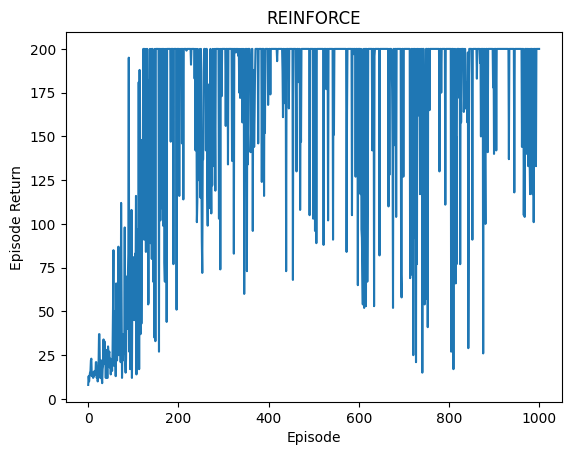

In [165]:
# JIT the choose_action and learn functions for more speed
REINFORCE_learn_jit = jax.jit(REINFORCE_learn)
REINFORCE_choose_action_jit = jax.jit(REINFORCE_choose_action)

# Initial learn state
REINFORCE_learn_state = REINFORCELearnState(REINFORCE_optim_state)

# Run training loop
print("Starting training. This may take up to 10 minutes to complete.")
episode_returns, evaluator_returns = run_training_loop(
                                        env_name,
                                        REINFORCE_params,
                                        REINFORCE_choose_action_jit,
                                        None, # action state not used
                                        REINFORCE_learn_jit,
                                        REINFORCE_learn_state,
                                        REINFORCE_memory,
                                        num_episodes=1001,
                                        learn_steps_per_episode=2,
                                        video_subdir="reinforce"
                                      )

# Plot the episode returns
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Episode Return")
plt.title("REINFORCE")
plt.show()


Работает.

In [167]:
#@title Визуализация {display-mode: "form"}
#@markdown Выберите номер эпизода, менее или равного 1000, и **run this cell**.

episode_number = 1000 #@param {type:"number"}

assert (episode_number % 100) == 0, "Episode number must be a multiple of 100 since we only record every 100th episode."
assert episode_number < 1001, "Episode number must be less than or equal to 1000"

eval_episode_number = int(episode_number / 100 * 8)
video_path = f"./video/reinforce/eval/rl-video-episode-{eval_episode_number}.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

Выглядит, как если бы играл человек.

In [174]:
# Implement a function takes q-values as input and returns the greedy_action
select_greedy_action = lambda q_values: jax.numpy.argmax (q_values)

In [175]:
# @title Проверка упр 10 (run me) {display-mode: "form"}

try:
  q_values = jnp.array([1,1,3,4])
  action = select_greedy_action(q_values)

  if action != 3:
    print("Incorrect answer, your greedy action selector looks wrong")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))


Looks good.


In [170]:
def build_network(num_actions: int, layers=[20, 20]) -> hk.Transformed:
  """Factory for a simple MLP network for approximating Q-values."""

  def q_network(obs):
    network = hk.Sequential(
        [hk.Flatten(),
         hk.nets.MLP(layers + [num_actions])])
    return network(obs)

  return hk.without_apply_rng(hk.transform(q_network))

In [171]:
# Initialise Q-network
Q_NETWORK = build_network(num_actions=num_actions, layers=[20, 20]) # two actions

dummy_obs = jnp.zeros((1,*obs_shape), jnp.float32) # a dummy observation like the one in CartPole

random_key = jax.random.PRNGKey(42) # random key
Q_NETWORK_PARAMS = Q_NETWORK.init(random_key, dummy_obs) # Get initial params

print("Q-Learning params:", Q_NETWORK_PARAMS.keys())

Q-Learning params: dict_keys(['mlp/~/linear_0', 'mlp/~/linear_1', 'mlp/~/linear_2'])


In [172]:
compute_squared_error = lambda pred, target: jax.numpy.square (target - pred)

In [173]:
#@title Проверка упр 11 {display-mode: "form"}

try:
  result = compute_squared_error(1, 4)

  if result != 9:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


**Упражнение 12:** Реализуйте функцию, которая вычисляет **цель Беллмана** (правая часть уравнения Беллмана). Если эпизод находится на последнем временном шаге (т. е. done==1.0), то цель Беллмана должна быть равна награде, без дополнительного значения в конце.

**Полезные функции**
* `jax.numpy.max` ([docs](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.max.html))

In [176]:
compute_bellman_target = lambda reward, done, next_q_values: reward + jax.numpy.max (next_q_values) * (1 - done)

In [177]:
#@title Проверка упр 12 {display-mode: "form"}

try:
  # not done
  result1 = compute_bellman_target(1, 0.0, np.array([3,2], "float32"))

  # done
  result2 = compute_bellman_target(1, 1.0, np.array([3,2], "float32"))

  if result1 != 4 or result2 != 1:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


Теперь мы можем объединить эти две функции, чтобы вычислить потерю для Q-обучения. Потери Q-обучения равны квадрату разницы между прогнозируемым значением Q действия и его соответствующей целью Беллмана.

**Упражнение 13:** Реализуйте функцию потери Q-обучения.

In [178]:
q_learning_loss = lambda q_values, action, reward, done, next_q_values: jax.numpy.square (q_values[action] - compute_bellman_target (reward, done, next_q_values))

In [179]:
#@title Проверка упр 13 {display-mode: "form"}

try:
  result = q_learning_loss(np.array([3,2], "float32"), 1, 2, 0.0, np.array([3,2], "float32"))

  if result != 9.0:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


In [181]:
# Store online and target parameters
QLearnParams = collections.namedtuple("Params", ["online", "target"])

# Q-learn-state
QLearnState = collections.namedtuple("LearnerState", ["count", "optim_state"])

In [182]:
# Initialise Q-network optimizer
Q_LEARN_OPTIMIZER = optax.adam(3e-4) # learning rate

Q_LEARN_OPTIM_STATE = Q_LEARN_OPTIMIZER.init(Q_NETWORK_PARAMS) # initial optim state

# Create Learn State
Q_LEARNING_LEARN_STATE = QLearnState(0, Q_LEARN_OPTIM_STATE) # count set to zero initially

# Add initial Q-network weights to QLearnParams object
Q_LEARNING_PARAMS = QLearnParams(online=Q_NETWORK_PARAMS, target=Q_NETWORK_PARAMS) # target equal to online

In [183]:
def update_target_params(learn_state, online_weights, target_weights):
  """A function to update target params every 100 training steps"""

  target = jax.lax.cond(
      jax.numpy.mod(learn_state.count, 100) == 0,
      lambda x, y: x,
      lambda x, y: y,
      online_weights,
      target_weights
  )

  params = QLearnParams(online_weights, target)

  return params

In [184]:
def batched_q_learning_loss(online_params, target_params, obs, actions, rewards, next_obs, dones):
    q_values = Q_NETWORK.apply(online_params, obs) # use the online parameters
    next_q_values = Q_NETWORK.apply(target_params, next_obs) # use the target parameters
    squared_error = jax.vmap(q_learning_loss)(q_values, actions, rewards, dones, next_q_values) # vmap q_learning_loss
    mean_squared_error = jnp.mean(squared_error) # mean squared error over batch
    return mean_squared_error

In [185]:
def q_learn(rng, params, learner_state, memory):
  # Compute gradients
  grad_loss = jax.grad(batched_q_learning_loss)(params.online, params.target, memory.obs,
                                          memory.action, memory.reward,
                                          memory.next_obs, memory.done,
                                          ) # jax.grad

  # Get updates
  updates, opt_state = Q_LEARN_OPTIMIZER.update(grad_loss, learner_state.optim_state)

  # Apply them
  new_weights = optax.apply_updates(params.online, updates)

  # Maybe update target network
  params = update_target_params(learner_state, new_weights, params.target)

  # Increment learner step counter
  learner_state = QLearnState(learner_state.count + 1, opt_state)

  return params, learner_state

In [186]:
class TransitionMemory(object):
  """A simple Python replay buffer."""

  def __init__(self, max_size=10_000, batch_size=256):
    self.batch_size = batch_size
    self.buffer = collections.deque(maxlen=max_size)

  def push(self, transition):

    # add transition to the replay buffer
    self.buffer.append(
        (transition.obs, transition.action, transition.reward,
          transition.next_obs, transition.done)
    )


  def is_ready(self):
    return self.batch_size <= len(self.buffer)

  def sample(self):
    # Randomly sample a batch of transitions from the buffer
    random_replay_sample = random.sample(self.buffer, self.batch_size)

    # Batch the transitions together
    obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = zip(*random_replay_sample)

    return Transition(
        np.stack(obs_batch).astype("float32"),
        np.asarray(action_batch).astype("int32"),
        np.asarray(reward_batch).astype("float32"),
        np.stack(next_obs_batch).astype("float32"),
        np.asarray(done_batch).astype("float32")
    )

# Instantiate the memory
Q_LEARNING_MEMORY = TransitionMemory(max_size=50_000, batch_size=256)

### Случайное исследование
У нас почти есть все, что нужно для функционирующего агента Q-обучения. Но одна проблема заключается в том, что если мы всегда выбираем действие с наивысшим значением Q, то политика агента будет полностью [детерминированной](https://www.quora.com/What-is-the-intuitive-difference-between-a-stochastic-model-and-a-deterministic-model). Это означает, что агент всегда будет выбирать одну и ту же стратегию. Это может представлять проблему, поскольку в начале обучения Q-сеть будет очень неточной (т. е. плохой аппроксимацией истинной Q-функции). Таким образом, агент будет последовательно выбирать неоптимальные действия. Более того, агент никогда не отклонится от своей неоптимальной стратегии и никогда не обнаружит новые, потенциально более полезные действия. В результате Q-сеть остается неточной. В идеале агент должен опробовать много разных стратегий, чтобы он мог наблюдать результаты (вознаграждения) своих действий в разных состояниях и таким образом улучшить приближение Q-функции.

Один простой способ гарантировать, что агент опробует много разных действий, — позволить ему периодически выбирать некоторые случайные действия вместо жадного (лучшего) действия все время.

**Упражнение 14:** Реализуйте функцию, которая, учитывая количество возможных (дискретных) действий, возвращает случайное действие.

**Полезные методы:**

*  `jax.random.randint` ([docs](https://jax.readthedocs.io/en/latest/_autosummary/jax.random.randint.html))

In [187]:
select_random_action = lambda key, num_actions: jax.random.randint(key, minval=0, maxval=num_actions, shape=())

In [194]:
#@title Проверка упр 14 {display-mode: "form"}

try:
  random_key1 = random_key = jax.random.PRNGKey(6) # random key
  random_key2 = random_key = jax.random.PRNGKey(1000) # random key
  result1 = select_random_action(random_key1, 2)
  result2 = select_random_action(random_key2, 2)
  print (result1, result2)

  if result1 != 1 or result2 != 0:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except:
  print("Your implementation looks wrong.")

0 0
Your implementation looks wrong.


Нормально там все, генератор случайных чисел такой.

### $\varepsilon$-greedy action selection (эпсилон жадный выбор действия)
В начале обучения, когда точность Q-сети низкая, агенту стоит в основном совершать случайные действия, чтобы он мог узнать, насколько хороши/плохи действия. Однако по мере повышения точности Q-сети агент должен начать совершать меньше случайных действий и вместо этого начать выбирать жадные действия относительно Q-значений. Выбор лучших действий с учетом текущей Q-сети называется **эксплуатацией**. В RL мы часто называем отношение случайных и жадных действий **эпсилоном** $\varepsilon$. Эпсилон обычно представляет собой десятичное значение в интервале $[0,1]$, где, например, $\varepsilon=0.4$ означает, что агент выбирает случайное действие в 40% случаев, а жадное действие — в 60% случаев. В RL принято линейно уменьшать значение эпсилон с течением времени, так что агент становится все более жадным по мере повышения точности его Q-сети в процессе обучения.

**Упражнение 15:** Реализуйте функцию, которая принимает количество временных шагов в качестве входных данных и возвращает текущее значение эпсилон.

In [195]:
EPSILON_DECAY_TIMESTEPS = 3000 # decay epsilon over 3000 timesteps
EPSILON_MIN = 0.1 # 10% exploration

In [263]:
get_epsilon = lambda num_timesteps: jax.lax.clamp(EPSILON_MIN, 1.0 - (num_timesteps/EPSILON_DECAY_TIMESTEPS), 1.0 ).astype("float32")

In [264]:
#@title Проверка упр 15 {display-mode: "form"}
def check_get_epsilon(get_epsilon):
    try:
        result1 = get_epsilon(10)
        result2 = get_epsilon(597010)
        print (result1, result2)

        if result1 != 0.99666667 or result2 != 0.1:
            print("Your function looks wrong.")
        else:
            print("Your function looks correct.")
    except:
        print("Your function looks wrong.")


check_get_epsilon(get_epsilon)

0.99666667 0.1
Your function looks correct.


**Упражнение 16:** Теперь давайте объединим эти функции для выполнения эпсилон-жадного выбора действия.

In [258]:
def select_epsilon_greedy_action(key, q_values, num_timesteps):
    num_actions = len(q_values) # number of available actions

    epsilon = get_epsilon(num_timesteps)

    should_explore = jax.random.uniform (shape=(), key=key, minval=0, maxval=1.0) < epsilon

    action = jax.lax.select(
        should_explore,
        select_random_action (key, num_actions),
        select_greedy_action (q_values) )

    return action

In [255]:
#@title Проверка упражнения 16 {display-mode: "form"}

try:
  rng = hk.PRNGSequence(jax.random.PRNGKey(42))
  dummy_q_values = jnp.array([0,1], jnp.float32)
  num_timesteps = 5010 # very greedy
  actions1 = []
  for i in range(10):
      actions1.append(int(select_epsilon_greedy_action(next(rng), dummy_q_values, num_timesteps)))

  num_timesteps = 0 # completly random
  actions2 = []
  for i in range(10):
      actions2.append(int(select_epsilon_greedy_action(next(rng), dummy_q_values, num_timesteps)))

  if actions1 != [1, 1, 0, 1, 1, 0, 1, 1, 1, 1] or actions2 != [0, 0, 0, 1, 1, 1, 1, 0, 0, 0]:
    print("Looks like something might be incorrect!", actions1, actions2)
  else:
    print("Looks correct!")
except:
  print("ЕГГОГ")

Looks like something might be incorrect! [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] [0, 0, 1, 1, 0, 1, 0, 1, 0, 0]


Да нормально.

In [256]:
# Actor state stores the current number of timesteps
QActorState = collections.namedtuple("ActorState", ["count"])

def q_learning_select_action(key, params, actor_state, obs, evaluation=False):
    obs = jnp.expand_dims(obs, axis=0) # add dummy batch dim
    q_values = Q_NETWORK.apply(params.online, obs)[0] # remove batch dim

    action = select_epsilon_greedy_action(key, q_values, actor_state.count)
    greedy_action = select_greedy_action(q_values)

    action = jax.lax.select(
        evaluation,
        greedy_action,
        action
    )

    next_actor_state = QActorState(actor_state.count + 1) # increment timestep counter

    return action, next_actor_state

Q_LEARNING_ACTOR_STATE = QActorState(0) # counter set to zero

Starting training. This may take up to 8 minutes to complete.
Episode: 0	Episode Return: 29.0	Average Episode Return: 29.0	Evaluator Episode Return: 9.75
Episode: 100	Episode Return: 10.0	Average Episode Return: 12.0	Evaluator Episode Return: 9.125
Episode: 200	Episode Return: 9.0	Average Episode Return: 9.9	Evaluator Episode Return: 9.5
Episode: 300	Episode Return: 13.0	Average Episode Return: 11.75	Evaluator Episode Return: 11.75
Episode: 400	Episode Return: 48.0	Average Episode Return: 52.7	Evaluator Episode Return: 55.125
Episode: 500	Episode Return: 142.0	Average Episode Return: 156.35	Evaluator Episode Return: 169.75
Episode: 600	Episode Return: 200.0	Average Episode Return: 198.05	Evaluator Episode Return: 198.625
Episode: 700	Episode Return: 197.0	Average Episode Return: 189.05	Evaluator Episode Return: 197.75
Episode: 800	Episode Return: 190.0	Average Episode Return: 186.55	Evaluator Episode Return: 193.375
Episode: 900	Episode Return: 200.0	Average Episode Return: 200.0	Evalu

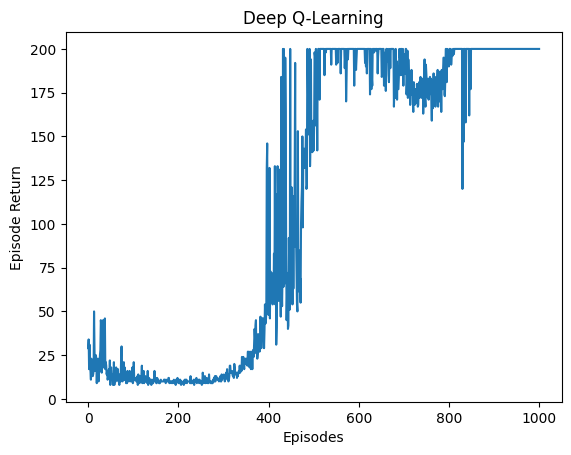

In [265]:
# Jit functions
q_learning_select_action_jit = jax.jit(q_learning_select_action)
q_learn_jit = jax.jit(q_learn)

# Run environment loop
print("Starting training. This may take up to 8 minutes to complete.")
episode_returns, evaluator_returns = run_training_loop(
                                        env_name,
                                        Q_LEARNING_PARAMS,
                                        q_learning_select_action_jit,
                                        Q_LEARNING_ACTOR_STATE,
                                        q_learn_jit,
                                        Q_LEARNING_LEARN_STATE,
                                        Q_LEARNING_MEMORY,
                                        num_episodes=1001,
                                        train_every_timestep=True, # do learning after every timestep
                                        video_subdir="q_learning"
                                    )

plt.plot(episode_returns)
plt.xlabel("Episodes")
plt.ylabel("Episode Return")
plt.title("Deep Q-Learning")
plt.show()

Работает лучше предыдущего варианта, однако перебор случайных методик подобрал годное решение быстрее - на второй сотне игр. В другой попытке, однако, случайный перебор не смог подобрать годный вариант за 1200 попыток, q-learning работает стабильнее и успевает.

In [266]:
#@title Визуализация политики
#@markdown Выберите номер эпизода, кратный 100 и меньший или равный 1000, и **запустите эту ячейку**.
episode_number = 900 #@param {type:"number"}

assert (episode_number % 100) == 0, "Episode number must be a multiple of 100 since we only record every 100th episode."
assert episode_number < 1001, "Episode number must be less than or equal to 1000"


eval_episode_number = int(episode_number / 100 * 8)
video_path = f"./video/q_learning/eval/rl-video-episode-{eval_episode_number}.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

Это... сильно.